In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Data Set:-
df = pd.read_csv(r"C:\Users\windows 10\Downloads\Covid_19_Clean_Complete (2).csv")

In [9]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [14]:
df.rename(columns ={'Province/State' : 'State' , 'Country/Region' : 'Country'} , inplace = True)

In [15]:
df

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [24]:
Conformed_cases = df.groupby(['Date'])['Confirmed'].sum().reset_index()

In [25]:
Conformed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [26]:
deats_daywise = df.groupby(['Date'])['Deaths'].sum().reset_index()

In [27]:
deats_daywise

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


# Visualization:-

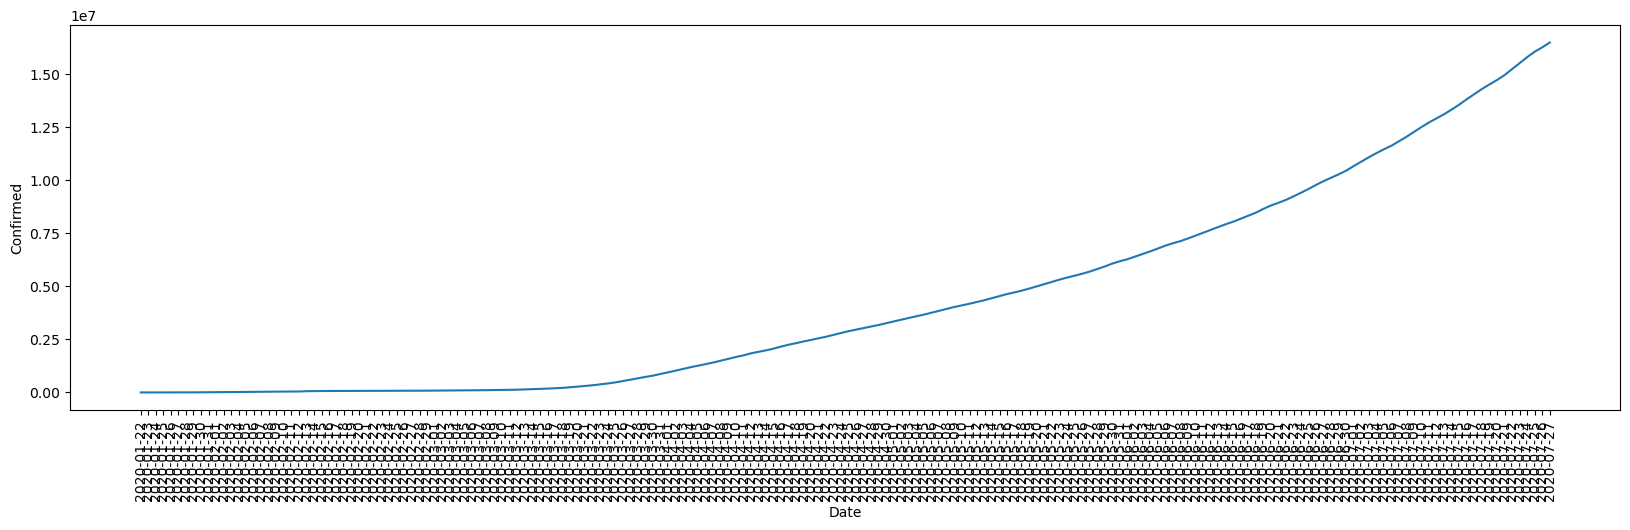

In [32]:
plt.figure(figsize = (20,5))
sns.lineplot(data = Conformed_cases, x= 'Date' , y = 'Confirmed')
plt.xticks(rotation = 90)
plt.show()

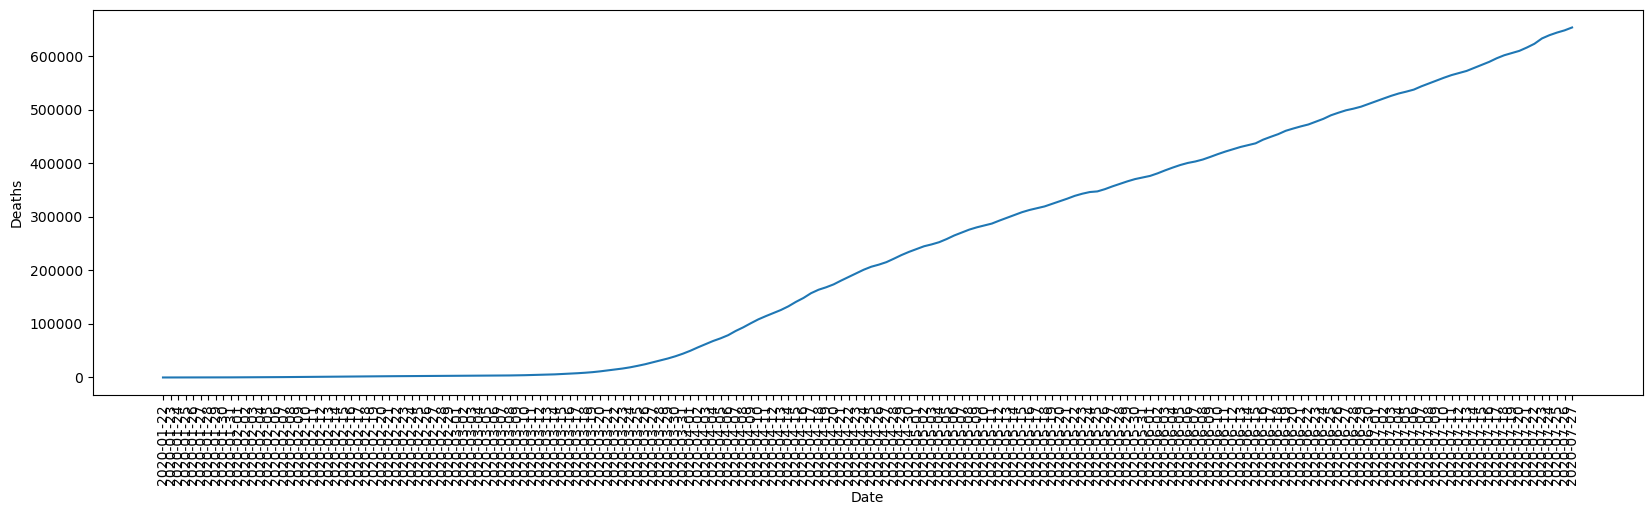

In [34]:
plt.figure(figsize = (20,5))
sns.lineplot(data =deats_daywise, x = 'Date',y = 'Deaths' )
plt.xticks(rotation = 90)
plt.show()

In [35]:
recovered_cases = df.groupby(['Date'])['Recovered'].sum().reset_index()

In [36]:
recovered_cases

,Date,Recovered
0,2020-01-22,28
1,2020-01-23,30
2,2020-01-24,36
3,2020-01-25,39
4,2020-01-26,52
...,...,...
183,2020-07-23,8710969
184,2020-07-24,8939705
185,2020-07-25,9158743
186,2020-07-26,9293464


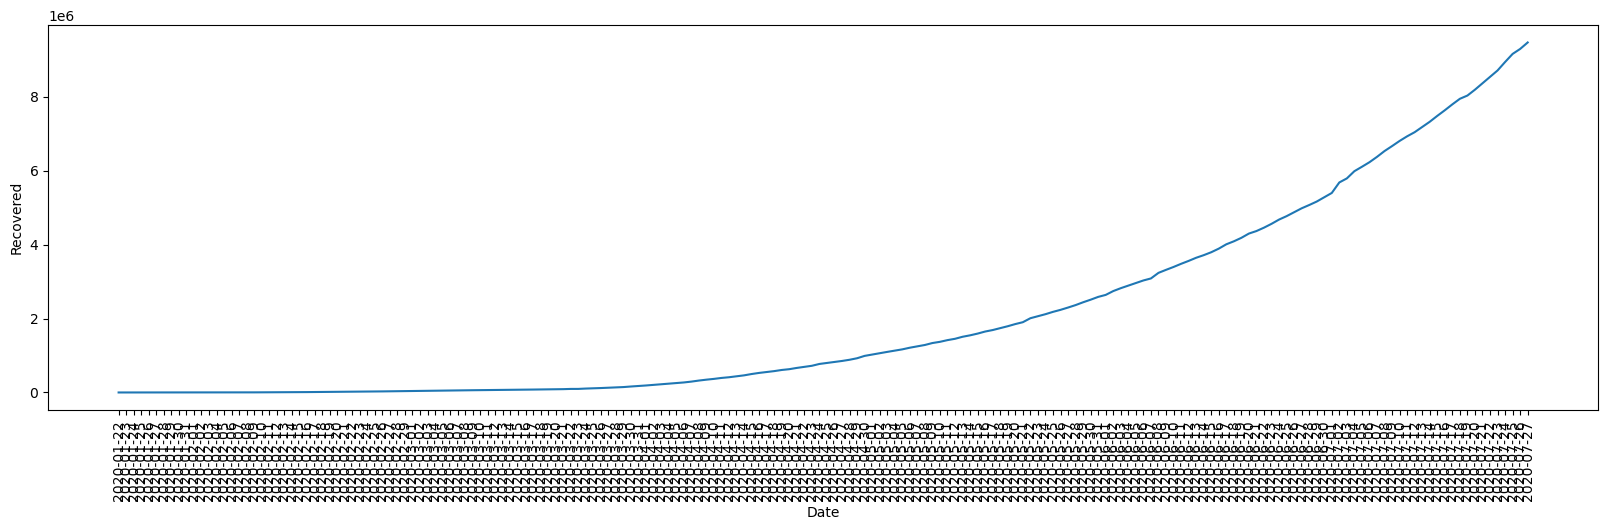

In [40]:
plt.figure(figsize = (20,5))
sns.lineplot(data= recovered_cases, x= 'Date',y = 'Recovered')
plt.xticks(rotation = 90)
plt.show()

In [41]:
active_cases = df.groupby(['Date'])['Active'].sum().reset_index()

In [42]:
active_cases

,Date,Active
0,2020-01-22,510
1,2020-01-23,606
2,2020-01-24,879
3,2020-01-25,1353
4,2020-01-26,2010
...,...,...
183,2020-07-23,6166006
184,2020-07-24,6212290
185,2020-07-25,6243930
186,2020-07-26,6309711


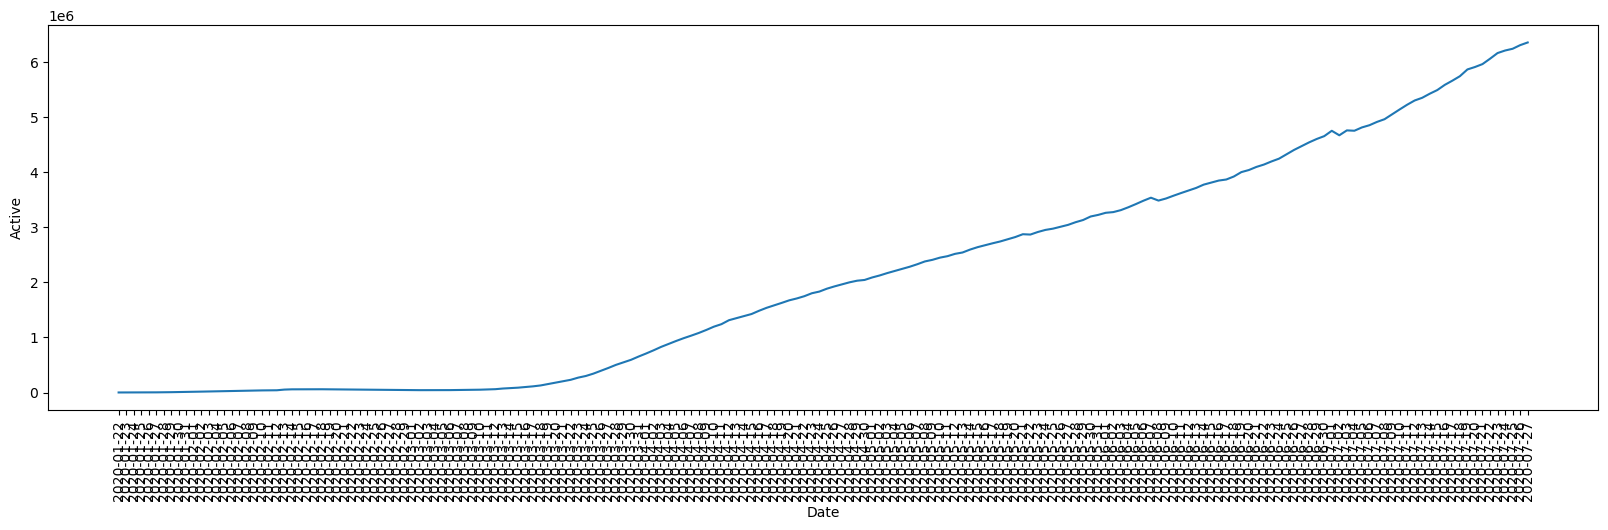

In [43]:
plt.figure(figsize =(20,5))
sns.lineplot(data = active_cases , x = 'Date' , y = 'Active' )
plt.xticks(rotation = 90)
plt.show()

# Most Effected Countryies:-

In [49]:
mostly_effected = df.groupby(['Country'])[['Confirmed','Active','Deaths','Recovered']].sum().reset_index()

In [50]:
mostly_effected

,Country,Confirmed,Active,Deaths,Recovered
0,Afghanistan,1936390,1089052,49098,798240
1,Albania,196702,72117,5708,118877
2,Algeria,1179755,345886,77972,755897
3,Andorra,94404,19907,5423,69074
4,Angola,22662,15011,1078,6573
...,...,...,...,...,...
182,West Bank and Gaza,233461,170967,1370,61124
183,Western Sahara,901,190,63,648
184,Yemen,67180,25694,17707,23779
185,Zambia,129421,43167,2643,83611


# How Much india Effected:- 

In [61]:
indias_data = mostly_effected[mostly_effected['Country'] == 'India']
indias_data

,Country,Confirmed,Active,Deaths,Recovered
79,India,40883464,15987913,1111831,23783720


# Top Five Most Effected Contries:-

In [52]:
top5effected = mostly_effected.sort_values(by = 'Confirmed', ascending = False).head(5)

In [54]:
print('ON THE BASES OF CONFORMED CASES:-')
top5effected

ON THE BASES OF CONFORMED CASES:-


,Country,Confirmed,Active,Deaths,Recovered
173,US,224345948,156981121,11011411,56353416
23,Brazil,89524967,31094060,3938034,54492873
138,Russia,45408411,19668578,619385,25120448
79,India,40883464,15987913,1111831,23783720
157,Spain,27404045,9277432,3033030,15093583


In [57]:
print('ON THE BASES OF DEATHS:- ')
top_5_deaths = mostly_effected.sort_values(by = 'Deaths' , ascending = False).head(5)
top_5_deaths

ON THE BASES OF DEATHS:- 


,Country,Confirmed,Active,Deaths,Recovered
173,US,224345948,156981121,11011411,56353416
177,United Kingdom,26748587,22624595,3997775,126217
23,Brazil,89524967,31094060,3938034,54492873
85,Italy,26745145,7363518,3707717,15673910
61,France,21210926,10980287,3048524,7182115


In [59]:
print('ON THE BASES OF RECOVERY:- ')
top_5_recovered = mostly_effected.sort_values(by = 'Recovered', ascending = False).head(5)
top_5_recovered

ON THE BASES OF RECOVERY:- 


,Country,Confirmed,Active,Deaths,Recovered
173,US,224345948,156981121,11011411,56353416
23,Brazil,89524967,31094060,3938034,54492873
138,Russia,45408411,19668578,619385,25120448
79,India,40883464,15987913,1111831,23783720
65,Germany,21059152,3079991,871322,17107839


# Visualisation:- 

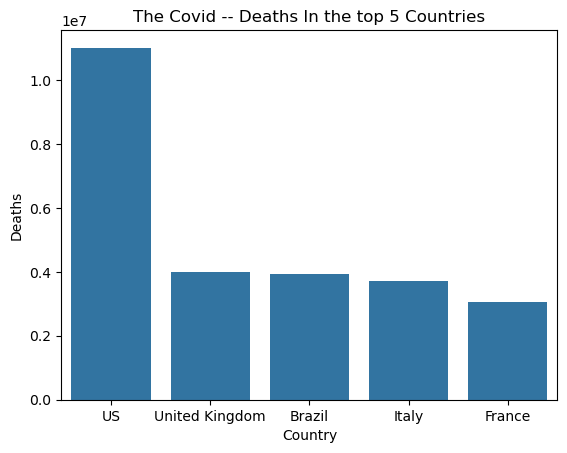

In [66]:
sns.barplot(data = top_5_deaths , x = 'Country' , y = 'Deaths')
plt.title('The Covid -- Deaths In the top 5 Countries')
plt.show()

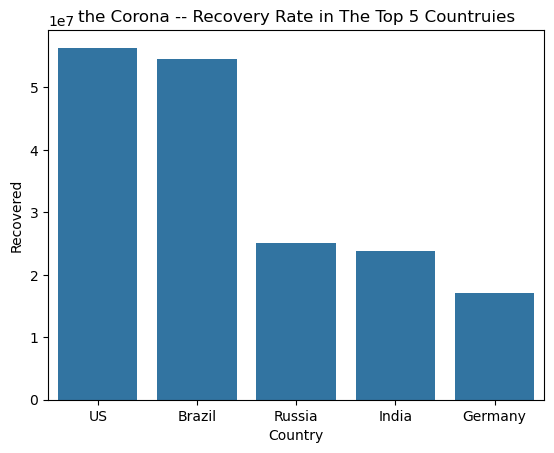

In [68]:
sns.barplot(data = top_5_recovered ,x= 'Country' , y = 'Recovered')
plt.title('the Corona -- Recovery Rate in The Top 5 Countruies')
plt.show()

In [73]:
us = df[df['Country'] == 'US']

In [74]:
us

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...,...
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas


In [75]:
data_us = us.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
data_us

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,1,0,0,1
1,2020-01-23,1,0,0,1
2,2020-01-24,2,0,0,2
3,2020-01-25,2,0,0,2
4,2020-01-26,5,0,0,5
...,...,...,...,...,...
183,2020-07-23,4038816,144430,1233269,2661117
184,2020-07-24,4112531,145560,1261624,2705347
185,2020-07-25,4178970,146465,1279414,2753091
186,2020-07-26,4233923,146935,1297863,2789125


In [76]:
brazil = df[df['Country'] == 'Brazil']
brazil

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
28,NaN,Brazil,-14.235,-51.9253,2020-01-22,0,0,0,0,Americas
289,NaN,Brazil,-14.235,-51.9253,2020-01-23,0,0,0,0,Americas
550,NaN,Brazil,-14.235,-51.9253,2020-01-24,0,0,0,0,Americas
811,NaN,Brazil,-14.235,-51.9253,2020-01-25,0,0,0,0,Americas
1072,NaN,Brazil,-14.235,-51.9253,2020-01-26,0,0,0,0,Americas
...,...,...,...,...,...,...,...,...,...,...
47791,NaN,Brazil,-14.235,-51.9253,2020-07-23,2287475,84082,1620313,583080,Americas
48052,NaN,Brazil,-14.235,-51.9253,2020-07-24,2343366,85238,1693214,564914,Americas
48313,NaN,Brazil,-14.235,-51.9253,2020-07-25,2394513,86449,1785359,522705,Americas
48574,NaN,Brazil,-14.235,-51.9253,2020-07-26,2419091,87004,1812913,519174,Americas


In [77]:
brazil_data = brazil.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
brazil_data

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,2287475,84082,1620313,583080
184,2020-07-24,2343366,85238,1693214,564914
185,2020-07-25,2394513,86449,1785359,522705
186,2020-07-26,2419091,87004,1812913,519174


In [78]:
russia = df[df['Country'] == 'Russia']
russia

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
185,NaN,Russia,61.52401,105.318756,2020-01-22,0,0,0,0,Europe
446,NaN,Russia,61.52401,105.318756,2020-01-23,0,0,0,0,Europe
707,NaN,Russia,61.52401,105.318756,2020-01-24,0,0,0,0,Europe
968,NaN,Russia,61.52401,105.318756,2020-01-25,0,0,0,0,Europe
1229,NaN,Russia,61.52401,105.318756,2020-01-26,0,0,0,0,Europe
...,...,...,...,...,...,...,...,...,...,...
47948,NaN,Russia,61.52401,105.318756,2020-07-23,793720,12873,579295,201552,Europe
48209,NaN,Russia,61.52401,105.318756,2020-07-24,799499,13026,587728,198745,Europe
48470,NaN,Russia,61.52401,105.318756,2020-07-25,805332,13172,596064,196096,Europe
48731,NaN,Russia,61.52401,105.318756,2020-07-26,811073,13249,599172,198652,Europe


In [79]:
russia_data = russia.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
russia_data

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,793720,12873,579295,201552
184,2020-07-24,799499,13026,587728,198745
185,2020-07-25,805332,13172,596064,196096
186,2020-07-26,811073,13249,599172,198652


# Compare those there most effected countries:-

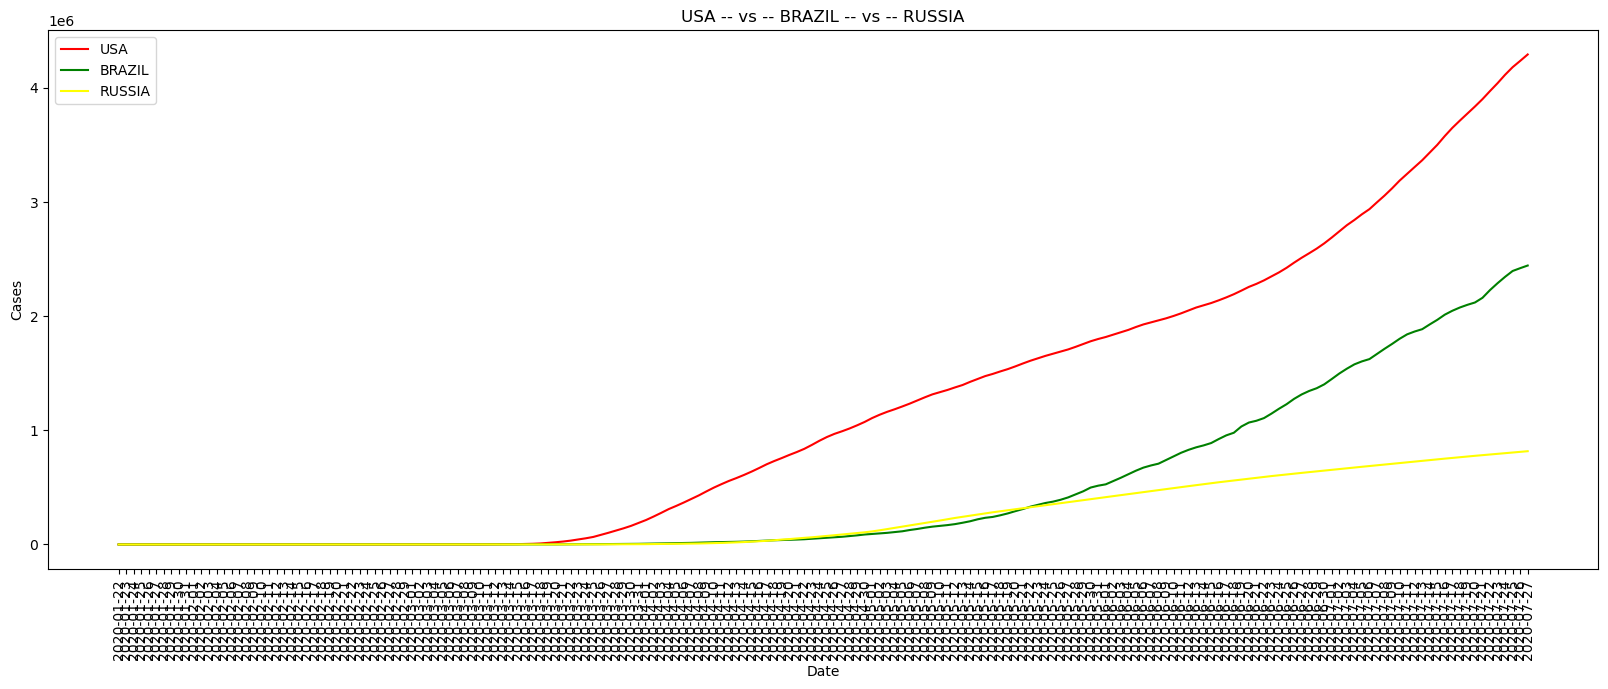

In [84]:
plt.figure(figsize = (20,7))
sns.lineplot(data = data_us , x = 'Date' , y = 'Confirmed', color = 'Red', label = 'USA')
sns.lineplot(data = brazil_data , x= 'Date', y = 'Confirmed' , color = 'Green', label = 'BRAZIL')
sns.lineplot(data = russia_data , x = 'Date' , y = 'Confirmed' , color = 'Yellow' , label = 'RUSSIA')
plt.xticks(rotation = 90)
plt.title('USA -- vs -- BRAZIL -- vs -- RUSSIA')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.show()

Now let me compare with "India"-- "pakistan" -- "Bangladesh" -- "China"

In [86]:
india_data = df[df['Country'] == 'India']

In [87]:
india_data = india_data.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
india_data

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,1288108,30601,817209,440298
184,2020-07-24,1337024,31358,849432,456234
185,2020-07-25,1385635,32060,885573,468002
186,2020-07-26,1435616,32771,917568,485277


In [89]:
bangla_data = df[df['Country'] == 'Bangladesh']

In [90]:
bangla_data = bangla_data.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
bangla_data

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,216110,2801,119208,94101
184,2020-07-24,218658,2836,120976,94846
185,2020-07-25,221178,2874,122090,96214
186,2020-07-26,223453,2928,123882,96643


In [91]:
pak_data = df[df['Country'] == 'Pakistan']
pak_data = pak_data.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
pak_data

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,270400,5763,219783,44854
184,2020-07-24,271887,5787,236596,29504
185,2020-07-25,273113,5822,237434,29857
186,2020-07-26,273113,5822,237434,29857


In [92]:
china_data = df[df['Country'] == 'China']
china_data = china_data.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
china_data

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,548,17,28,503
1,2020-01-23,643,18,30,595
2,2020-01-24,920,26,36,858
3,2020-01-25,1406,42,39,1325
4,2020-01-26,2075,56,49,1970
...,...,...,...,...,...
183,2020-07-23,86045,4649,78701,2695
184,2020-07-24,86202,4650,78745,2807
185,2020-07-25,86381,4652,78813,2916
186,2020-07-26,86570,4652,78862,3056


# Visualisation of Comparision:-

plt.figure(figsize = (20,7))
sns.lineplot(data = india_data, x = 'Date' , y= 'Deaths' , color = 'Blue' , label = 'INDIA' )
sns.lineplot(data = pak_data, x = 'Date' , y= 'Deaths' , color = 'Green' , label = 'PAk' )
sns.lineplot(data = bangla_data, x = 'Date' , y= 'Deaths' , color = 'Red' , label = 'BANGLA' )
sns.lineplot(data = china_data, x = 'Date' , y= 'Deaths' , color = 'Black' , label = 'CHINA' )
plt.title('INDIA -- PAK -- BANGLA -- CHINA (Death Rate)')
plt.xticks(rotation = 90)
plt.xlabel('Date')
plt.ylabel('Country')
plt.show()


# The Forcasting Model -- Prophet:-

In [97]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 4.5 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/12.1 MB 4.5 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.1 MB 4.5 MB/s eta 0:00:03
   ------------ --------------------------- 3.7/12.1 MB 4.4 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.1 MB 4.4 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.1 MB 4.3 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.1 MB 4.3 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.1 MB 4.4 MB/s eta 0:00:02
   --------------------------- ------------ 8.4/12.1 MB 4.4 MB/s eta 0:00:01
   ----------------------------- ---------- 8.9/12.1 MB 4.4 MB/s eta 0:00:01
   -------------------------------- ------- 10.0/12.1 MB 4.4 MB/s eta 0:00:01
   ------------------------------------ --- 11.0/12.1 MB 4.4 MB/s eta 0:00:01
   -

In [106]:
from prophet import Prophet


In [102]:
Conformed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


As we know that the prophet only work with the two columns which are dt(date stamp) and the y(the forecasting column)
so we should rename the columns:-

In [103]:
prophet_data = Conformed_cases.rename(columns ={'Date' : 'ds' , 'Confirmed' : 'y'})

In [104]:
prophet_data

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [107]:
FCM = Prophet()

In [108]:
FCM.fit(prophet_data)

07:33:23 - cmdstanpy - INFO - Chain [1] start processing
07:33:24 - cmdstanpy - INFO - Chain [1] done processing


# Prediction:-

In [109]:
future = FCM.make_future_dataframe(periods = 7) # for next 7 days

In [116]:
future

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [117]:
forecast = FCM.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.356181e+03,-1.220324e+05,8.709893e+04,-9.356181e+03,-9.356181e+03,-10986.215104,-10986.215104,-10986.215104,-10986.215104,-10986.215104,-10986.215104,0.0,0.0,0.0,-2.034240e+04
1,2020-01-23,-6.667726e+03,-1.088945e+05,9.543782e+04,-6.667726e+03,-6.667726e+03,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,0.0,0.0,0.0,-7.746619e+03
2,2020-01-24,-3.979272e+03,-9.601087e+04,1.074062e+05,-3.979272e+03,-3.979272e+03,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,0.0,0.0,0.0,6.123982e+03
3,2020-01-25,-1.290817e+03,-9.774007e+04,1.239471e+05,-1.290817e+03,-1.290817e+03,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,0.0,0.0,0.0,1.237940e+04
4,2020-01-26,1.397637e+03,-9.971742e+04,1.239869e+05,1.397637e+03,1.397637e+03,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,0.0,0.0,0.0,8.615785e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674928e+07,1.664017e+07,1.685362e+07,1.674208e+07,1.675489e+07,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,0.0,0.0,0.0,1.674820e+07
191,2020-07-31,1.695352e+07,1.684364e+07,1.706515e+07,1.694113e+07,1.696572e+07,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,0.0,0.0,0.0,1.696362e+07
192,2020-08-01,1.715776e+07,1.705631e+07,1.727449e+07,1.713745e+07,1.717769e+07,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,0.0,0.0,0.0,1.717143e+07
193,2020-08-02,1.736200e+07,1.725566e+07,1.748148e+07,1.733152e+07,1.739117e+07,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,0.0,0.0,0.0,1.736922e+07


In [118]:
forecast[['yhat_lower','yhat_upper', 'yhat']]

,yhat_lower,yhat_upper,yhat
0,-1.220324e+05,8.709893e+04,-2.034240e+04
1,-1.088945e+05,9.543782e+04,-7.746619e+03
2,-9.601087e+04,1.074062e+05,6.123982e+03
3,-9.774007e+04,1.239471e+05,1.237940e+04
4,-9.971742e+04,1.239869e+05,8.615785e+03
...,...,...,...
190,1.664017e+07,1.685362e+07,1.674820e+07
191,1.684364e+07,1.706515e+07,1.696362e+07
192,1.705631e+07,1.727449e+07,1.717143e+07
193,1.725566e+07,1.748148e+07,1.736922e+07


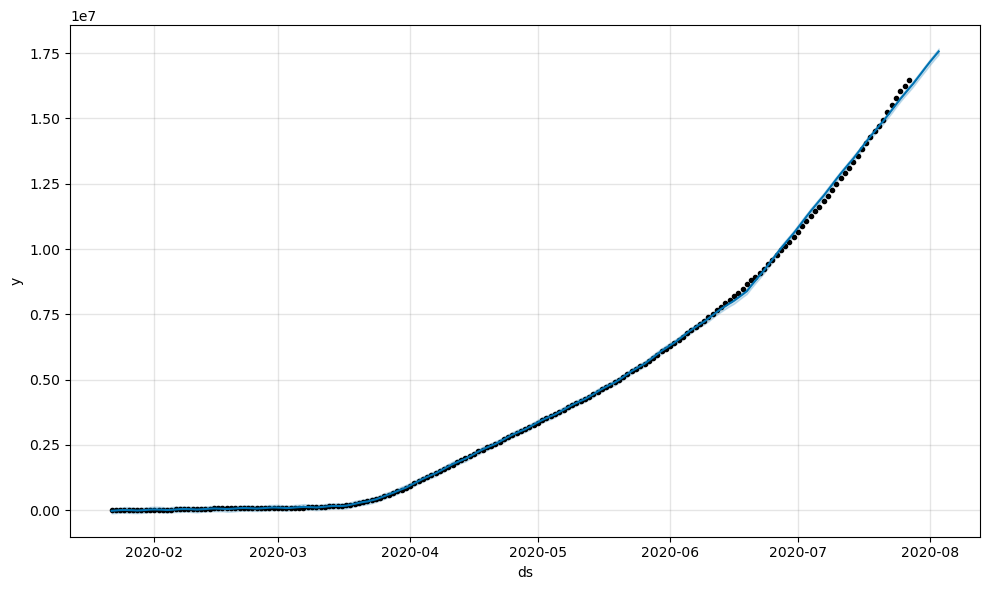

In [119]:
FCM.plot(forecast)
plt.show()

The Extra Line is the Prediction

# The Death Forecasting:-

In [120]:
death_cases = df.groupby('Date')['Deaths'].sum().reset_index()

In [121]:
death_cases

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [134]:
death_cases = death_cases.rename(columns ={'Date' : 'ds' , 'Deaths' : 'y'})

In [135]:
death_cases

,ds,y
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56
...,...,...
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621


In [136]:
model = Prophet ()

In [137]:
model.fit(death_cases)

09:18:25 - cmdstanpy - INFO - Chain [1] start processing
09:18:26 - cmdstanpy - INFO - Chain [1] done processing


In [140]:
future_col = model.make_future_dataframe(periods = 31)

In [141]:
future_col

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
214,2020-08-23
215,2020-08-24
216,2020-08-25
217,2020-08-26


In [142]:
future_col_forecasting = model.predict(future_col)

In [143]:
future_col_forecasting

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-521.770784,-2592.552442,1131.066365,-521.770784,-521.770784,-191.377481,-191.377481,-191.377481,-191.377481,-191.377481,-191.377481,0.0,0.0,0.0,-713.148265
1,2020-01-23,-432.731501,-1914.734458,2025.008971,-432.731501,-432.731501,388.586602,388.586602,388.586602,388.586602,388.586602,388.586602,0.0,0.0,0.0,-44.144900
2,2020-01-24,-343.692219,-1623.878178,2461.349546,-343.692219,-343.692219,874.803913,874.803913,874.803913,874.803913,874.803913,874.803913,0.0,0.0,0.0,531.111694
3,2020-01-25,-254.652937,-1431.237530,2461.478025,-254.652937,-254.652937,727.302005,727.302005,727.302005,727.302005,727.302005,727.302005,0.0,0.0,0.0,472.649068
4,2020-01-26,-165.613654,-2202.958927,1666.817766,-165.613654,-165.613654,-165.700009,-165.700009,-165.700009,-165.700009,-165.700009,-165.700009,0.0,0.0,0.0,-331.313663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,2020-08-23,783877.046234,765014.020662,804783.997635,764975.369980,804490.922992,-165.700009,-165.700009,-165.700009,-165.700009,-165.700009,-165.700009,0.0,0.0,0.0,783711.346226
215,2020-08-24,788908.048531,768215.834033,810580.583912,769120.419372,811238.678910,-905.322648,-905.322648,-905.322648,-905.322648,-905.322648,-905.322648,0.0,0.0,0.0,788002.725883
216,2020-08-25,793939.050828,772010.835241,817187.068978,773090.576843,817447.938603,-728.292382,-728.292382,-728.292382,-728.292382,-728.292382,-728.292382,0.0,0.0,0.0,793210.758446
217,2020-08-26,798970.053125,775990.711782,824267.415628,776694.910554,823918.803771,-191.377481,-191.377481,-191.377481,-191.377481,-191.377481,-191.377481,0.0,0.0,0.0,798778.675643


In [144]:
future_col_forecasting[['yhat_upper','yhat_lower','yhat']]

,yhat_upper,yhat_lower,yhat
0,1131.066365,-2592.552442,-713.148265
1,2025.008971,-1914.734458,-44.144900
2,2461.349546,-1623.878178,531.111694
3,2461.478025,-1431.237530,472.649068
4,1666.817766,-2202.958927,-331.313663
...,...,...,...
214,804783.997635,765014.020662,783711.346226
215,810580.583912,768215.834033,788002.725883
216,817187.068978,772010.835241,793210.758446
217,824267.415628,775990.711782,798778.675643


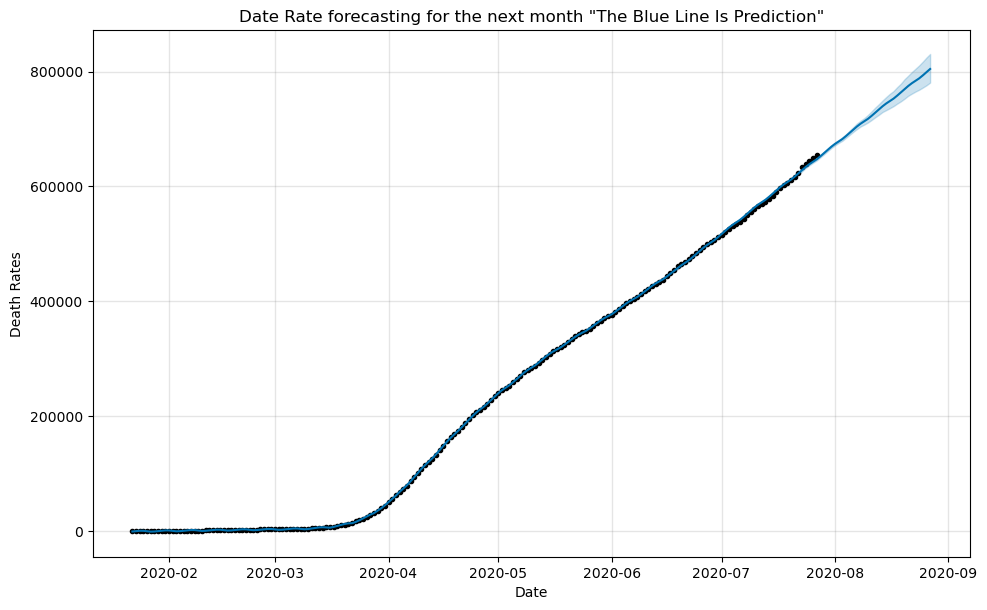

In [146]:
model.plot(future_col_forecasting)
plt.xlabel('Date')
plt.ylabel('Death Rates')
plt.title('Date Rate forecasting for the next month "The Blue Line Is Prediction"')
plt.show()